![BeliefLens](assets/belieflens-notebook-header.png)

# Apply a frozen BeliefLens calibration inside LangChain

## Goal

Show how a LangChain or LangGraph workflow can convert an already observed language-probability vector into calibrated probabilities over **Risk-on**, **Mixed**, and **Risk-off** without calling a hosted BeliefLens service.

## What happens

1. Load the frozen financial benchmark schema and JSON calibration map.
2. Select one archived language measurement.
3. Apply the declared additive-log-ratio transformation and frozen multinomial calibration locally.
4. Return calibrated state probabilities through a LangChain runnable.
5. Route the next workflow action using the resulting uncertainty decision.
6. Record the real execution as OpenTelemetry spans and optionally inspect it in Jaeger.

This notebook makes **zero BeliefLens API calls and zero model-provider calls**. It does not refit calibration. The CPU work is a few logarithms and a small matrix multiplication. Code inputs are hidden by default; outputs remain visible.

**Further information:** [BeliefLens primer](https://belieflens.org/#/primer) · [Software and integration guide](https://belieflens.org/#/software) · [Benchmark Lab](https://belieflens.org/#/benchmarks)


## 1. Prepare a small LangChain kernel

Only `langchain-core` is needed. To avoid changing dependencies in a large shared environment, create a small kernel from this repository:

```bash
python3 -m venv .venv-belieflens-langchain
source .venv-belieflens-langchain/bin/activate
python -m pip install --upgrade pip
python -m pip install "langchain-core>=0.3,<1" ipykernel numpy pandas matplotlib opentelemetry-sdk opentelemetry-exporter-otlp-proto-http
python -m ipykernel install --user --name belieflens-langchain --display-name "BeliefLens + LangChain"
```

Then select **Kernel → Change Kernel → BeliefLens + LangChain**. No BeliefLens API key is required for this local example.


In [1]:
from pathlib import Path
import hashlib, json, os
import numpy as np
import pandas as pd
from langchain_core.runnables import RunnableLambda

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path('examples/notebooks/finance')
BUNDLE = ROOT / 'data' / 'offline_reproduction'
assert BUNDLE.exists(), f'Frozen finance bundle not found: {BUNDLE.resolve()}'
print('Local LangChain calibration environment is ready.')


Local LangChain calibration environment is ready.


## 2. Load the frozen measurement profile

The JSON file is the fitted measurement channel. It declares the response candidates, the additive-log-ratio transformation, the state ordering, regularization setting, coefficients, intercept and calibration-record identifiers. Loading it applies an existing calibration; it does not estimate a new one.


In [2]:
profile_path = BUNDLE / 'semantic_map.json'
profile = json.loads(profile_path.read_text())
profile_hash = hashlib.sha256(profile_path.read_bytes()).hexdigest()

pd.Series({
    'schema': profile['schema_version'],
    'states': ', '.join(profile['states']),
    'input candidates': ', '.join(profile['input_candidates']),
    'transformation': profile['input_transform'],
    'calibration records': len(profile['calibration_scenario_ids']),
    'profile SHA-256': profile_hash,
}, name='Frozen local measurement profile')


schema                                 belieflens-frozen-semantic-map-v1
states                                          Risk-on, Mixed, Risk-off
input candidates                        Risk-on, Mixed, Risk-off, Unsure
transformation                         additive log ratio against Unsure
calibration records                                                  180
profile SHA-256        ff93a18afd9362aa1f14746c797e0cba2fb0076c2c5cab...
Name: Frozen local measurement profile, dtype: object

## 3. Define the local calibrated measurement

The runnable expects probabilities over the four controlled language responses: Risk-on, Mixed, Risk-off and Unsure. It forms three log ratios against Unsure, applies the frozen coefficient matrix and intercept, and normalizes the resulting scores with the softmax function. The output is a probability distribution over the three declared financial states.

In a live workflow, an upstream provider-specific node would supply the phrase probabilities. Here we use an archived vector so the example remains deterministic, free and auditable.

The calibration is the statistical contribution; LangChain does not make the probabilities more accurate. Its contribution is operational: the same measurement becomes a standard runnable node that can be composed with upstream evidence/model nodes, executed in batches, traced, retried and connected to conditional downstream actions.


In [3]:
ACCEPTANCE_THRESHOLD = 0.80  # Illustrative; validate and freeze for a real workflow.
MINIMUM_MARGIN = 0.15       # Illustrative separation from the second state.

def apply_frozen_calibration(value, frozen_profile, frozen_profile_sha256):
    states = frozen_profile['states']
    candidates = frozen_profile['input_candidates']
    coefficients = np.asarray(frozen_profile['coefficients'], dtype=float)
    intercept = np.asarray(frozen_profile['intercept'], dtype=float)
    supplied = value['language_probabilities']
    probabilities = np.asarray([float(supplied[name]) for name in candidates], dtype=float)
    if np.any(probabilities <= 0) or not np.isclose(probabilities.sum(), 1.0, atol=1e-6):
        raise ValueError('Language probabilities must be positive and sum to one.')

    alr = np.log(probabilities[:3] / probabilities[3])
    scores = coefficients @ alr + intercept
    calibrated = np.exp(scores - scores.max())
    calibrated /= calibrated.sum()
    state_probabilities = dict(zip(states, calibrated.tolist()))
    leading_state = max(state_probabilities, key=state_probabilities.get)
    leading_probability = state_probabilities[leading_state]
    ordered = sorted(state_probabilities.values(), reverse=True)
    probability_margin = ordered[0] - ordered[1]
    normalized_entropy = float(-np.sum(calibrated * np.log(calibrated)) / np.log(len(calibrated)))
    acceptance_checks = [
        {
            'name': 'leading-state probability',
            'observed': leading_probability,
            'criterion': f'>= {ACCEPTANCE_THRESHOLD:.2f}',
            'passed': leading_probability >= ACCEPTANCE_THRESHOLD,
        },
        {
            'name': 'separation from second state',
            'observed': probability_margin,
            'criterion': f'>= {MINIMUM_MARGIN:.2f}',
            'passed': probability_margin >= MINIMUM_MARGIN,
        },
    ]
    failed_checks = [check for check in acceptance_checks if not check['passed']]
    decision = 'measurement_accepted_within_scope' if not failed_checks else 'measurement_valid_state_ambiguous'
    reasons = [
        f"{check['name']} was {check['observed']:.3f}; required {check['criterion']}"
        for check in failed_checks
    ]
    return {
        **value,
        'state_probabilities': state_probabilities,
        'leading_state': leading_state,
        'leading_probability': leading_probability,
        'probability_margin': probability_margin,
        'normalized_entropy': normalized_entropy,
        'acceptance_checks': acceptance_checks,
        'reasons': reasons,
        'decision': decision,
        'measurement_profile_sha256': frozen_profile_sha256,
        'execution_mode': 'local_frozen_calibration',
        'provider_calls': 0,
        'belieflens_api_calls': 0,
    }

measurement = RunnableLambda(lambda value: apply_frozen_calibration(value, profile, profile_hash))
print('Local calibrated measurement runnable created.')


Local calibrated measurement runnable created.


## 4. Invoke the measurement as a LangChain node

The archived row supplies the observable language probabilities and the previously stored calibrated probabilities. The latter are used only as a reproduction check: the runnable must recover them from the JSON map to numerical precision.

The raw language channel is almost certain about Risk-on, but the historical calibration map reduces that probability substantially. This is precisely why the workflow should inspect calibrated state uncertainty rather than treating the largest raw language probability as an automatic action.


In [4]:
rows = pd.read_csv(BUNDLE / 'row_level_measurements.csv')
archived = rows.iloc[0]
record = {
    'measurement_id': 'spy-regime-v5:example-001',
    'observation_id': archived['scenario_id'],
    'evidence_date': archived['date'],
    'language_probabilities': {
        'Risk-on': archived['raw_risk_on'],
        'Mixed': archived['raw_mixed'],
        'Risk-off': archived['raw_risk_off'],
        'Unsure': archived['raw_unsure'],
    },
}
result = measurement.invoke(record)

archived_calibrated = np.asarray([
    archived['calibrated_risk_on'], archived['calibrated_mixed'], archived['calibrated_risk_off']
])
locally_calibrated = np.asarray([result['state_probabilities'][state] for state in profile['states']])
reproduction_error = float(np.max(np.abs(archived_calibrated - locally_calibrated)))

print(json.dumps({
    'observation_id': result['observation_id'],
    'language_probabilities': result['language_probabilities'],
    'calibrated_state_probabilities': result['state_probabilities'],
    'leading_state': result['leading_state'],
    'leading_probability': result['leading_probability'],
    'probability_margin': result['probability_margin'],
    'normalized_entropy': result['normalized_entropy'],
    'acceptance_checks': result['acceptance_checks'],
    'decision': result['decision'],
    'reasons': result['reasons'],
    'maximum_reproduction_error': reproduction_error,
    'BeliefLens API calls': result['belieflens_api_calls'],
    'provider calls': result['provider_calls'],
}, indent=2))
assert reproduction_error < 1e-12


{
  "observation_id": "daily-2018-01-10",
  "language_probabilities": {
    "Risk-on": 0.999999999997,
    "Mixed": 1.0000228884425302e-12,
    "Risk-off": 1.0000228884425302e-12,
    "Unsure": 1.0000228884425302e-12
  },
  "calibrated_state_probabilities": {
    "Risk-on": 0.6308426961449894,
    "Mixed": 0.3453985594919225,
    "Risk-off": 0.02375874436308812
  },
  "leading_state": "Risk-on",
  "leading_probability": 0.6308426961449894,
  "probability_margin": 0.28544413665306695,
  "normalized_entropy": 0.679638863118121,
  "acceptance_checks": [
    {
      "name": "leading-state probability",
      "observed": 0.6308426961449894,
      "criterion": ">= 0.80",
      "passed": false
    },
    {
      "name": "separation from second state",
      "observed": 0.28544413665306695,
      "criterion": ">= 0.15",
      "passed": true
    }
  ],
  "decision": "measurement_valid_state_ambiguous",
  "reasons": [
    "leading-state probability was 0.631; required >= 0.80"
  ],
  "maximum_re

## 5. Gate the next LangGraph action

The calibrated distribution—not a printed confidence number—becomes part of the workflow state. A conditional edge can continue, request review or abstain before a trade or other consequential tool call. The threshold below illustrates orchestration; it is not an investment-policy recommendation.

For this observation, human review means only that the prespecified automatic-acceptance gate was not met. It is not a claim that the Risk-on state is wrong. The leading calibrated probability is displayed alongside the failed criterion so the route is auditable. In production, thresholds must be selected and frozen from validation and operational costs—not chosen after seeing this example.


In [5]:
def route_measurement(state):
    decision = state['measurement']['decision']
    if decision == 'measurement_accepted_within_scope':
        return 'continue'
    if 'abstain' in decision:
        return 'abstain'
    return 'human_review'

route = route_measurement({'measurement': result})
print('Next workflow route:', route)
print('Why:', '; '.join(result['reasons']) if result['reasons'] else 'All acceptance checks passed.')

# graph.add_conditional_edges('measure', route_measurement, {
#     'continue': 'action', 'human_review': 'review', 'abstain': 'stop'
# })


Next workflow route: human_review
Why: leading-state probability was 0.631; required >= 0.80


## 6. Trace the LangChain workflow

The earlier notebook did **not** enable tracing; it only noted that LangChain workflows can be traced. This section enables it.

- **LangChain** composes the executable steps: `observe | calibrate | gate`.
- **BeliefLens** performs the statistical measurement inside `calibrate`, using the frozen JSON map.
- **OpenTelemetry** records the execution as parent-child spans.
- **Jaeger** is an optional viewer for those spans; it neither calibrates probabilities nor changes the decision.

An in-memory trace is enabled by default, so this example remains local and key-free. If `OTEL_EXPORTER_OTLP_ENDPOINT` is set, the same spans are also exported to Jaeger.


In [6]:
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
from opentelemetry.sdk.trace.export.in_memory_span_exporter import InMemorySpanExporter

provider = TracerProvider(resource=Resource.create({'service.name':'belieflens-langchain-local'}))
memory_exporter = InMemorySpanExporter()
provider.add_span_processor(SimpleSpanProcessor(memory_exporter))
endpoint = os.getenv('OTEL_EXPORTER_OTLP_ENDPOINT')
if endpoint:
    from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter
    provider.add_span_processor(SimpleSpanProcessor(OTLPSpanExporter(endpoint=endpoint)))
tracer = provider.get_tracer('belieflens.langchain.measurement')

def observe(value):
    with tracer.start_as_current_span('observe.language_probabilities') as span:
        span.set_attribute('measurement.id', str(value['measurement_id']))
        span.set_attribute('observation.id', str(value['observation_id']))
        return value

def calibrate(value, frozen_profile):
    with tracer.start_as_current_span('measure.semantic_calibration') as span:
        out = apply_frozen_calibration(value, frozen_profile, profile_hash)
        span.set_attribute('measurement.id', str(value['measurement_id']))
        span.set_attribute('measurement.leading_state', out['leading_state'])
        span.set_attribute('measurement.leading_probability', out['leading_probability'])
        span.set_attribute('measurement.decision', out['decision'])
        return out

def gate(value):
    with tracer.start_as_current_span('governance.acceptance_gate') as span:
        next_route = route_measurement({'measurement':value})
        span.set_attribute('measurement.id', str(value['measurement_id']))
        span.set_attribute('governance.route', next_route)
        span.set_attribute('governance.failed_checks', len(value['reasons']))
        return {'measurement':value, 'route':next_route}

# Actual LangChain Expression Language (LCEL) syntax
belieflens = RunnableLambda(lambda value: calibrate(value, profile))
chain = RunnableLambda(observe) | belieflens | RunnableLambda(gate)
memory_exporter.clear()
with tracer.start_as_current_span('langchain.workflow') as workflow_span:
    workflow_span.set_attribute('measurement.id', record['measurement_id'])
    traced_result = chain.invoke(record)
provider.force_flush()
spans = list(memory_exporter.get_finished_spans())
trace_table = pd.DataFrame([{
    'span':s.name,
    'parent span':f'{s.parent.span_id:016x}' if s.parent else '—',
    'duration (ms)':(s.end_time-s.start_time)/1e6,
    'decision / route':s.attributes.get('measurement.decision',s.attributes.get('governance.route',''))
} for s in spans])
print('LangChain: chain = observe | calibrate | gate')
print('Resulting route:', traced_result['route'])
print('Tracing:', 'local + Jaeger' if endpoint else 'local in-memory')
trace_table


LangChain: chain = observe | calibrate | gate
Resulting route: human_review
Tracing: local in-memory


,span,parent span,duration (ms),decision / route
0,observe.language_probabilities,240dc4094dfe4a22,0.007,
1,measure.semantic_calibration,240dc4094dfe4a22,0.060,measurement_valid_state_ambiguous
2,governance.acceptance_gate,240dc4094dfe4a22,0.005,human_review
3,langchain.workflow,—,2.376,


### LangChain syntax and Jaeger-style trace

This clean diagram is generated from the spans above—not from an image model. Its left side shows the actual LangChain expression; its right side shows the recorded parent-child trace in the style of Jaeger. The table reports actual timings.


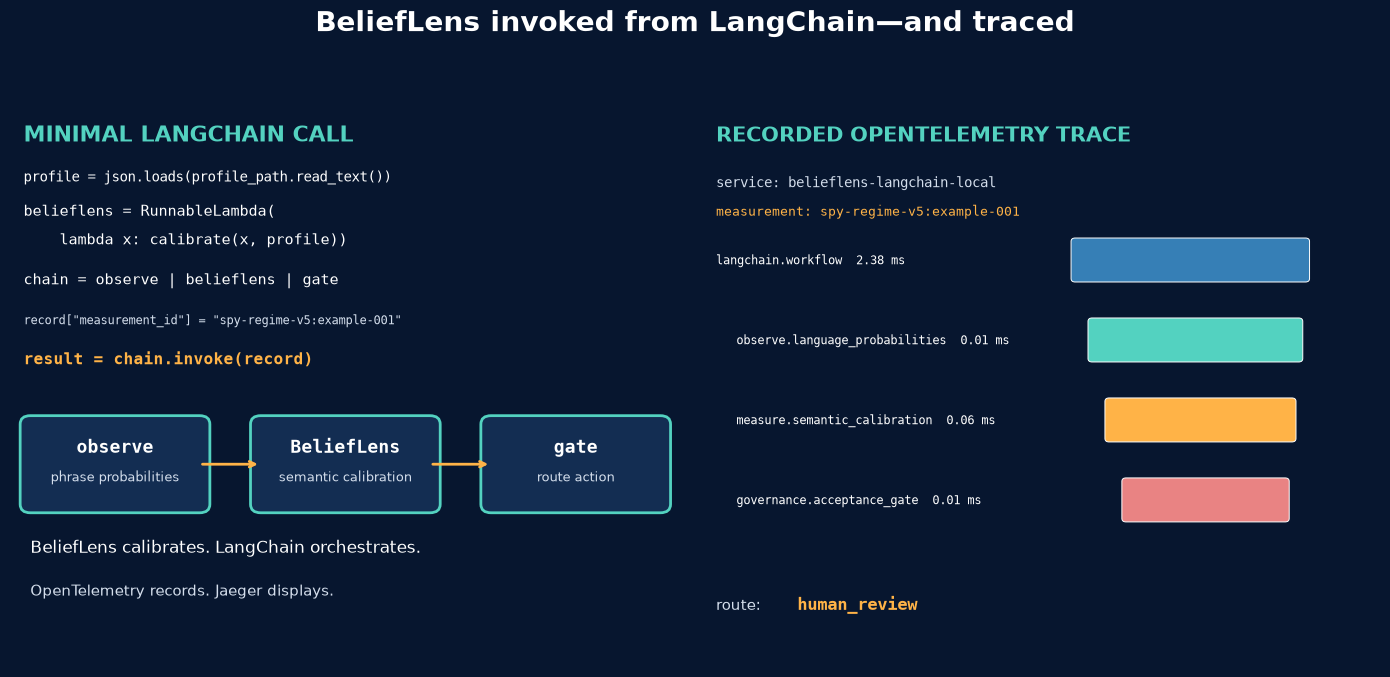

Saved: /private/tmp/belieflens-repro-strategy/examples/notebooks/finance/assets/langchain-jaeger-trace.png


In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
fig,(a,b)=plt.subplots(1,2,figsize=(14,7)); fig.patch.set_facecolor('#07162f')
for ax in (a,b): ax.set_facecolor('#07162f'); ax.axis('off')
a.text(.02,.92,'MINIMAL LANGCHAIN CALL',color='#53d2c0',size=16,weight='bold')
a.text(.02,.85,'profile = json.loads(profile_path.read_text())',color='white',size=9.8,family='monospace')
a.text(.02,.79,'belieflens = RunnableLambda(',color='white',size=10.5,family='monospace')
a.text(.02,.74,'    lambda x: calibrate(x, profile))',color='white',size=10.5,family='monospace')
a.text(.02,.67,'chain = observe | belieflens | gate',color='white',size=10.5,family='monospace')
a.text(.02,.60,'record["measurement_id"] = "spy-regime-v5:example-001"',color='#d4deec',size=8.8,family='monospace')
a.text(.02,.53,'result = chain.invoke(record)',color='#ffb347',size=11.8,weight='bold',family='monospace')
items=[(.03,'observe','phrase probabilities'),(.37,'BeliefLens','semantic calibration'),(.71,'gate','route action')]
for x,t,s in items:
 a.add_patch(FancyBboxPatch((x,.285),.25,.14,boxstyle='round,pad=.015',facecolor='#132d52',edgecolor='#53d2c0',lw=2))
 a.text(x+.125,.375,t,ha='center',color='white',size=13,weight='bold',family='monospace'); a.text(x+.125,.325,s,ha='center',color='#d4deec',size=9)
for x,y in [(.28,.37),(.62,.71)]: a.annotate('',(y,.355),(x,.355),arrowprops={'arrowstyle':'->','color':'#ffb347','lw':2})
a.text(.03,.20,'BeliefLens calibrates. LangChain orchestrates.',color='white',size=12)
a.text(.03,.125,'OpenTelemetry records. Jaeger displays.',color='#d4deec',size=11)
b.text(.02,.92,'RECORDED OPENTELEMETRY TRACE',color='#53d2c0',size=15,weight='bold')
b.text(.02,.84,'service: belieflens-langchain-local',color='#d4deec',size=10,family='monospace')
b.text(.02,.79,'measurement: '+record['measurement_id'],color='#ffb347',size=9.5,family='monospace')
order=['langchain.workflow','observe.language_probabilities','measure.semantic_calibration','governance.acceptance_gate']
colors=['#367fb6','#53d2c0','#ffb347','#e98383']
span_by_name={s.name:s for s in spans}
for i,(name,col) in enumerate(zip(order,colors)):
 y=.68-i*.14
 duration=(span_by_name[name].end_time-span_by_name[name].start_time)/1e6
 b.text(.02+(.03 if i else 0),y+.025,f'{name}  {duration:.2f} ms',color='white',size=8.8,family='monospace')
 b.add_patch(FancyBboxPatch((.55+i*.025,y),.34-i*.035,.065,boxstyle='round,pad=.006',facecolor=col,edgecolor='white',lw=.7))
b.text(.02,.10,'route:',color='#d4deec',size=11); b.text(.14,.10,traced_result['route'],color='#ffb347',size=12,weight='bold',family='monospace')
fig.suptitle('BeliefLens invoked from LangChain—and traced',color='white',size=20,weight='bold')
fig.tight_layout(rect=(0,.02,1,.94))
path=ROOT/'assets'/'langchain-jaeger-trace.png'; fig.savefig(path,dpi=180,facecolor=fig.get_facecolor(),bbox_inches='tight'); plt.show()
print('Saved:',path.resolve())


### Optional Jaeger viewer

Start Jaeger, set its OTLP endpoint, then restart the notebook kernel and rerun:

```bash
docker run --rm -d --name belieflens-jaeger -p 16686:16686 -p 4318:4318 jaegertracing/all-in-one:latest
export OTEL_EXPORTER_OTLP_ENDPOINT=http://localhost:4318/v1/traces
```

Open [http://localhost:16686](http://localhost:16686), select **`belieflens-langchain-local`**, and click **Find Traces**. Without that environment variable, no trace leaves the notebook; the local table and figure still work.


## What this integration provides

LangChain supplies **orchestration**, not calibration: it composes the observation, measurement and routing steps. The frozen BeliefLens JSON supplies the **statistical measurement**. OpenTelemetry supplies **execution evidence**, while Jaeger is simply an optional trace viewer.

Here, `human_review` does not mean that Risk-on is wrong. It means the calibrated leading probability (0.631) did not reach the illustrative 0.80 threshold required for unattended action. The chain therefore preserves the measurement and its reason, but routes the case to a person rather than silently converting ambiguity into an automated trade.

The example remains completely local: zero provider calls, zero hosted BeliefLens calls and no API key.
